Gavin Hahn 
ASTRO 19 Group Project

In [51]:
# Imports
import numpy as np
from astropy.io import ascii
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle
from scipy import optimize

# Radial Velocity Curve file path
#FILE_PATH = '/Users/gavinhahn/Desktop/RadialVelocityCurve.txt'
FILE_PATH = 'RadialVelocityCurve.txt'

try: 
    data_rvc = ascii.read(FILE_PATH)
    print(data_rvc[:5])
except FileNotFoundError:
    raise FileNotFoundError(f"File not found at: {FILE_PATH}")

     HJD      Radial_Velocity Radial_Velocity_Uncertainty
     days          m / s                 m / s           
------------- --------------- ---------------------------
 2449676.0632   131.910003662                   4.8400002
2449767.77441   22.6000003815                   2.5699999
2449768.83203  -5.48999977112                   2.6800001
2449793.79785   107.309997559                        1.52
2450056.98828   116.669998169                   1.6199999


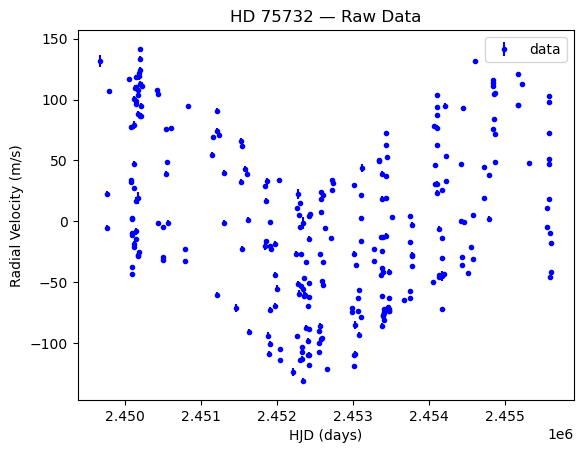

In [52]:
# x_col: Time (HJD days) // y_col: Radial Velocity (m/s) // yerror (m/s)
x_col = [a[0] for a in data_rvc]
y_col = [a[1] for a in data_rvc]
yerror = [a[2] for a in data_rvc]

# Convert to NP arrays
x = np.array(x_col)
y = np.array(y_col)
ye = np.array(yerror)

# Display Raw data
plt.errorbar(x,y,yerr=yerror,fmt="bo",ms=3,label='data')
plt.xlabel('HJD (days)')
plt.ylabel('Radial Velocity (m/s)')
plt.title('HD 75732 — Raw Data')
plt.legend()
plt.show()

Initial Estimates:
------------------
Lomb-Scargle best period guess: 14.6513 days
Amplitude Estimate: 136.0150 m/s
Initial X: 2449676.0632 days
Mean Radial Velocity: 0.5599 m/s

Best Estimates:
------------------
Best Amplitude  : -74.4935 ± 0.1286 m/s
Best x start    : 2449678.9817 ± 0.0103 days
Best Period     : 14.6515 ± 0.0000 days
Best Rad Velocity (mean): 4.5558 ± 0.0929 m/s



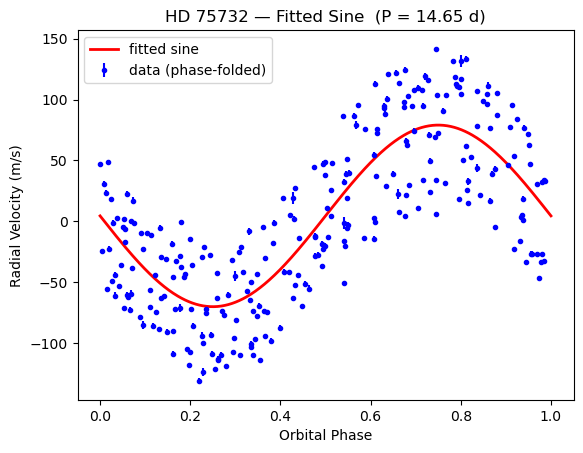

In [53]:
# Oscillatory Model
def f_model(x,a,b,c,d):
    return a*np.sin(2*np.pi*(x-b)/c) + d

# Estimate Best Period
ls = LombScargle(x, y, ye)
freq, power = ls.autopower(minimum_frequency=1/6000, maximum_frequency=1)
best_period = 1.0 / freq[np.argmax(power)]

# Other Parameter Estimates
amplitude = (y.max()-y.min())/2
x_start = x[0]
mean_radial_velocity = np.mean(y)

print("Initial Estimates:")
print("------------------")
print(f"Lomb-Scargle best period guess: {best_period:.4f} days")
print(f"Amplitude Estimate: {amplitude:.4f} m/s")
print(f"Initial X: {x_start:.4f} days")
print(f"Mean Radial Velocity: {mean_radial_velocity:.4f} m/s\n")

guess_params = [amplitude, x_start, best_period, mean_radial_velocity]

# Fit curve to data
best_params , _ = optimize.curve_fit(f_model,x,y,p0=guess_params,sigma=ye,absolute_sigma=True)
best_a, best_b, best_c, best_d = best_params

perr = np.sqrt(np.diag(_))   # Uncertainties

# Print Best Estimates
print("Best Estimates:")
print("------------------")
print(f"Best Amplitude  : {best_a:.4f} ± {perr[0]:.4f} m/s")
print(f"Best x start    : {best_b:.4f} ± {perr[1]:.4f} days")
print(f"Best Period     : {best_c:.4f} ± {perr[2]:.4f} days")
print(f"Best Rad Velocity (mean): {best_d:.4f} ± {perr[3]:.4f} m/s\n")

# Start x at best_b, mod, and normalize
phase = ((x - best_b) % best_c) / best_c

phi_grid = np.linspace(0, 1, 500)
y_fit    = f_model(phi_grid * best_c + best_b,
                   best_a, best_b, best_c, best_d)

# Display Fitted Curve and Phase-Folded Data
plt.figure()
plt.errorbar(phase, y, yerr=ye, fmt='bo', ms=3, label='data (phase-folded)')
plt.plot(phi_grid, y_fit, 'r-', lw=2, label='fitted sine')
plt.xlabel('Orbital Phase')
plt.ylabel('Radial Velocity (m/s)')
plt.title(f'HD 75732 — Fitted Sine  (P = {best_c:.2f} d)')
plt.legend(loc=0)
plt.show()

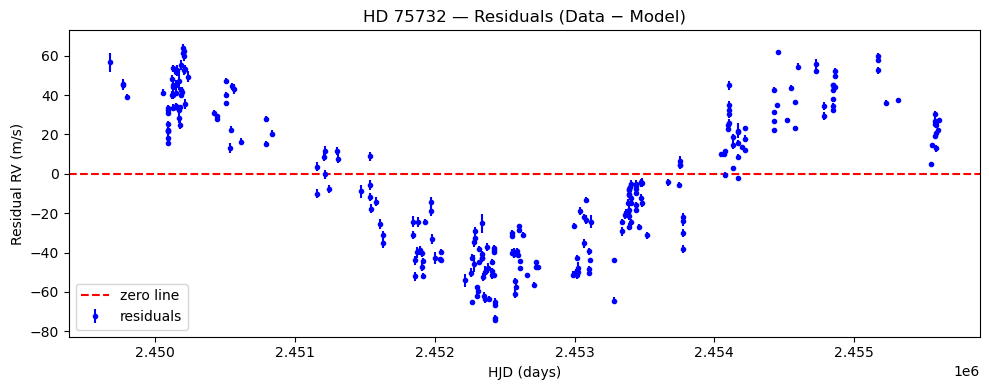

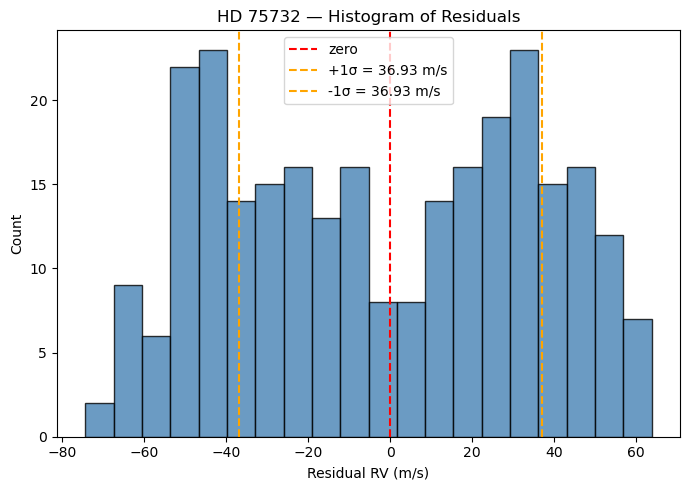

Residual std dev      : 36.9324 m/s
Mean experimental err : 1.8061 m/s
Ratio (std / mean_err): 20.4491


In [54]:
# Residuals

# Residuals (difference between model and data)
y_model = f_model(x, best_a, best_b, best_c, best_d)
residuals = y - y_model

# Plot residuals
fig, ax = plt.subplots(figsize=(10, 4))
ax.errorbar(x, residuals, yerr=ye, fmt='bo', ms=3, label='residuals')
ax.axhline(0, color='r', linestyle='--', lw=1.5, label='zero line')
ax.set_xlabel('HJD (days)')
ax.set_ylabel('Residual RV (m/s)')
ax.set_title('HD 75732 — Residuals (Data − Model)')
ax.legend()
plt.tight_layout()
plt.show()

# Histogram of residuals
residual_std = np.std(residuals)
mean_error   = np.mean(ye)

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(residuals, bins=20, color='steelblue', edgecolor='black', alpha=0.8)
ax.axvline(0, color='r', linestyle='--', lw=1.5, label='zero')
ax.axvline( residual_std, color='orange', linestyle='--', lw=1.5, label=f'+1σ = {residual_std:.2f} m/s')
ax.axvline(-residual_std, color='orange', linestyle='--', lw=1.5, label=f'-1σ = {residual_std:.2f} m/s')
ax.set_xlabel('Residual RV (m/s)')
ax.set_ylabel('Count')
ax.set_title('HD 75732 — Histogram of Residuals')
ax.legend()
plt.tight_layout()
plt.show()

# Quantitative comparison
print(f"Residual std dev      : {residual_std:.4f} m/s")
print(f"Mean experimental err : {mean_error:.4f} m/s")
print(f"Ratio (std / mean_err): {residual_std / mean_error:.4f}")


The residual standard deviation is high in comparison to the mean experimental error. This means that a single sinusoidal model is not enough to fully describe the radial velocity. There are likely other planets in this system with larger/shorter periods that influence the radial velocity over intervals that are less apparent in this set of data. 

We can calculate the mass of the exoplanet that found in the RV data by using the formula: 
    Mass(exoplanet) = (K/(28.4m/s)) x (P/(365 days))^1/3 x Mass(55 Cnc)^2/3
Where K is amplitude in m/s, P is period in days, Mass(exoplanet) is in multiples of Jupiter masses, and Mass(55 Cnc) is in solar masses.

We find that mass of the exoplanet is ~0.831-0.934 Jupiter masses which means the exoplanet is likely 55 Cnc b which has been estimated between 0.80 and 0.84 Jupiter masses.